In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\temp\\fmcg.csv")

df.shape
df.head()
df.info()
df.describe()
# Dataset contains transactional retail sales data including sales amount, profit, discount, region, channel and product information.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Invoice_ID            5000 non-null   object 
 1   date                  5000 non-null   object 
 2   category              5000 non-null   object 
 3   sku                   5000 non-null   object 
 4   region                5000 non-null   object 
 5   channel               5000 non-null   object 
 6   price                 5000 non-null   float64
 7   quantity              5000 non-null   int64  
 8   discount              5000 non-null   float64
 9   revenue               5000 non-null   int64  
 10  Cost_Per_Unit         5000 non-null   float64
 11  Profit                5000 non-null   int64  
 12  Customer_Type         5000 non-null   object 
 13  Payment_Method        5000 non-null   object 
 14  Promotion             5000 non-null   object 
 15  Month                

,price,quantity,discount,revenue,Cost_Per_Unit,Profit,Month,Year,Gross_Sales,Discount_Value,Calculated_Net_Sales
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03
mean,77306.181770,24.592800,5.431820,1.893236e+06,59229.560640,4.413602e+05,6.534400,2023.995000,1.893236e+06,1.098694e+05,1.783367e+06
std,23442.341173,33.675484,5.204569,2.761925e+06,18593.476001,6.606657e+05,3.406162,0.818235,2.761925e+06,2.554563e+05,2.613077e+06
min,30452.590000,1.000000,0.000000,3.839800e+04,20353.710000,6.117000e+03,1.000000,2023.000000,3.839800e+04,0.000000e+00,3.457000e+04
25%,58254.730000,4.000000,2.060000,3.134500e+05,44100.685000,6.814150e+04,4.000000,2023.000000,3.134500e+05,8.227000e+03,2.956172e+05
50%,69936.560000,9.000000,4.000000,6.329290e+05,54128.840000,1.475095e+05,7.000000,2024.000000,6.329290e+05,2.446500e+04,6.039620e+05
75%,97982.732500,32.000000,5.840000,2.176386e+06,73841.587500,4.672468e+05,10.000000,2025.000000,2.176386e+06,8.261000e+04,2.030070e+06
max,160943.780000,156.000000,24.940000,1.834655e+07,122279.900000,5.150518e+06,12.000000,2025.000000,1.834655e+07,3.484029e+06,1.736684e+07


In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df = df.drop_duplicates()

In [11]:
df.isnull().sum()

Invoice_ID              0
date                    0
category                0
sku                     0
region                  0
channel                 0
price                   0
quantity                0
discount                0
revenue                 0
Cost_Per_Unit           0
Profit                  0
Customer_Type           0
Payment_Method          0
Promotion               0
Month                   0
Year                    0
Gross_Sales             0
Discount_Value          0
Calculated_Net_Sales    0
dtype: int64

In [15]:
df['month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year
df['profit_margin'] = df['Profit'] / df['revenue']


In [17]:
df.head()

,Invoice_ID,date,category,sku,region,channel,price,quantity,discount,revenue,...,Payment_Method,Promotion,Month,Year,Gross_Sales,Discount_Value,Calculated_Net_Sales,month,year,profit_margin
0,INV-00001,2023-01-01,Snacks,SN-007,Shiraz,Pharmacy,55904.04,6,4.00,335424,...,Card,No,1,2023,335424,13417,322007,2023-01,2023,0.177671
1,INV-00002,2023-01-01,Dairy,DA-009,Tehran,Online,101091.20,6,14.83,606547,...,Transfer,Yes,1,2023,606547,89951,516596,2023-01,2023,0.211052
2,INV-00003,2023-01-02,Snacks,SN-100,Tehran,Wholesale,67767.29,4,2.38,271069,...,Card,No,1,2023,271069,6451,264618,2023-01,2023,0.126267
3,INV-00004,2023-01-02,Beverages,BE-135,Shiraz,Pharmacy,70094.95,56,1.77,3925317,...,Card,No,1,2023,3925317,69478,3855839,2023-01,2023,0.241229
4,INV-00005,2023-01-02,Dairy,DA-110,Shiraz,Online,104608.72,7,3.72,732261,...,Transfer,No,1,2023,732261,27240,705021,2023-01,2023,0.275854


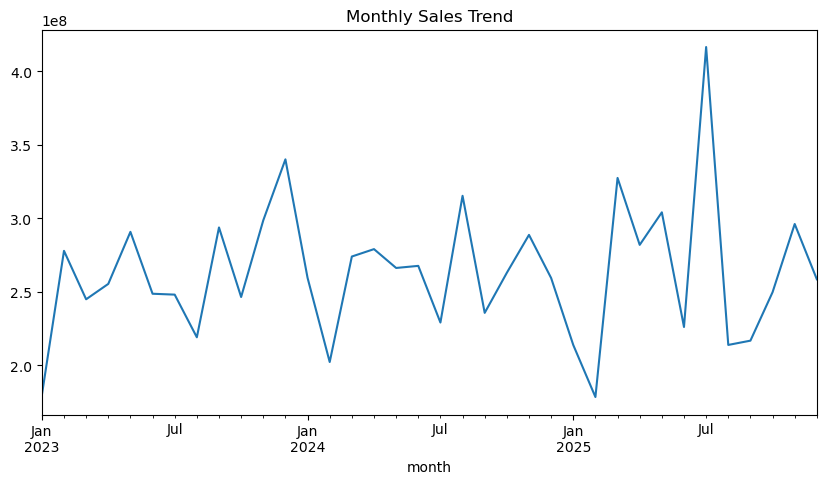

In [19]:
monthly_sales = df.groupby('month')['revenue'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()


In [23]:
mom_growth = monthly_sales.pct_change() * 100

In [24]:
mom_growth

month
2023-01          NaN
2023-02    54.700473
2023-03   -11.864750
2023-04     4.275040
2023-05    13.873758
2023-06   -14.487792
2023-07    -0.241269
2023-08   -11.708077
2023-09    34.135297
2023-10   -16.113970
2023-11    21.179172
2023-12    13.897784
2024-01   -23.709779
2024-02   -22.082256
2024-03    35.513820
2024-04     1.837537
2024-05    -4.593294
2024-06     0.533599
2024-07   -14.410116
2024-08    37.659950
2024-09   -25.270971
2024-10    11.584286
2024-11     9.804142
2024-12   -10.169391
2025-01   -17.582313
2025-02   -16.560354
2025-03    83.614140
2025-04   -13.914746
2025-05     7.858789
2025-06   -25.665042
2025-07    84.304836
2025-08   -48.675833
2025-09     1.361247
2025-10    15.215699
2025-11    18.593125
2025-12   -12.707378
Freq: M, Name: revenue, dtype: float64

<Axes: xlabel='profit_margin', ylabel='Count'>

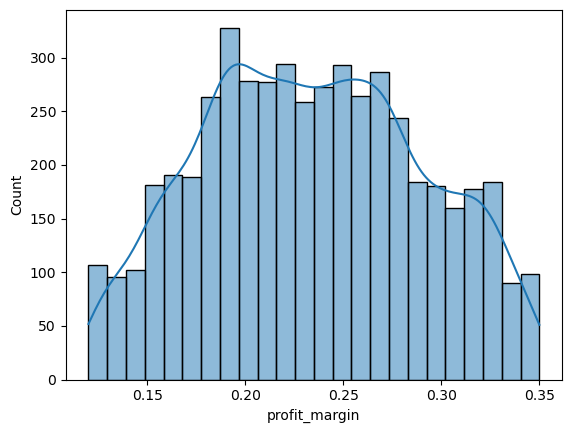

In [25]:
sns.histplot(df['profit_margin'], kde=True)


<Axes: xlabel='discount', ylabel='Profit'>

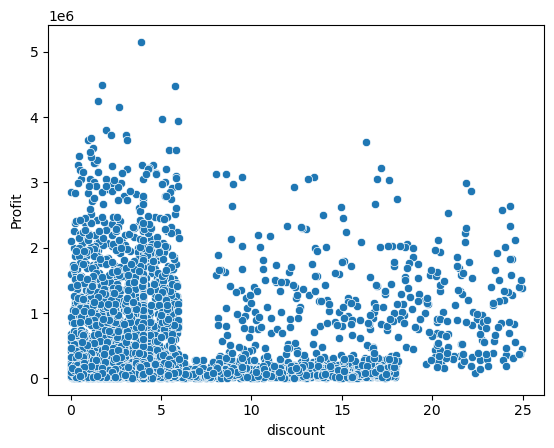

In [28]:
sns.scatterplot(x='discount', y='Profit', data=df)
#Higher discount levels reduce profitability.



In [30]:
top_products = df.groupby('sku')['revenue'].sum().sort_values(ascending=False).head(10)


In [31]:
top_products

sku
PE-090    70871515
PE-081    57989151
DA-088    56954222
DA-020    55516059
DA-134    48355925
DA-064    46953470
DA-017    45134467
PE-100    43551697
PE-130    43038831
DA-137    42064283
Name: revenue, dtype: int64

In [33]:
product_sales = df.groupby('sku')['revenue'].sum().sort_values(ascending=False)
cumulative = product_sales.cumsum() / product_sales.sum()


In [34]:
cumulative

sku
PE-090    0.007487
PE-081    0.013613
DA-088    0.019629
DA-020    0.025494
DA-134    0.030602
            ...   
HO-127    0.999917
DA-059    0.999951
PE-140    0.999973
DA-089    0.999994
HO-075    1.000000
Name: revenue, Length: 750, dtype: float64

In [35]:
n_products = len(cumulative)
pareto_threshold = cumulative[cumulative <= 0.8].shape[0]  # تا جایی که به 80٪ فروش برسیم
share = pareto_threshold / n_products * 100

print(f"{share:.1f}% از محصولات، 80% فروش را ساخته‌اند.")

53.1% از محصولات، 80% فروش را ساخته‌اند.


In [36]:
region_sales = df.groupby('region')['revenue'].sum()
channel_sales = df.groupby('channel')['revenue'].sum()


In [37]:
region_sales

region
Ahvaz      1672882065
Isfahan    1473316368
Mashhad    1537733102
Shiraz     1782425877
Tabriz     1446464051
Tehran     1553360295
Name: revenue, dtype: int64

In [38]:
channel_sales

channel
Hypermarket    1950772917
Online         1591139034
Pharmacy       1477471077
Supermarket    1878849142
Wholesale      2567949588
Name: revenue, dtype: int64

<Axes: >

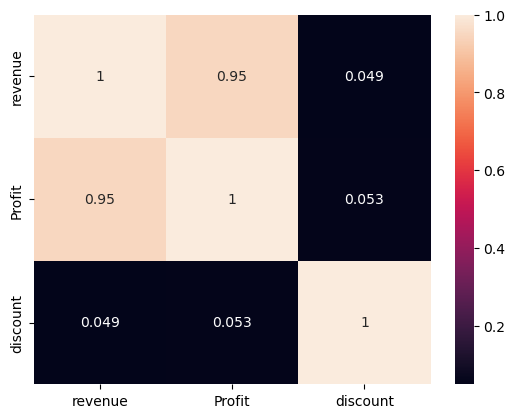

In [39]:
sns.heatmap(df[['revenue','Profit','discount']].corr(), annot=True)


In [40]:
monthly_sales_rolling = monthly_sales.rolling(3).mean()


In [41]:
monthly_sales_rolling

month
2023-01             NaN
2023-02             NaN
2023-03    2.341247e+08
2023-04    2.593752e+08
2023-05    2.636853e+08
2023-06    2.649415e+08
2023-07    2.625079e+08
2023-08    2.385835e+08
2023-09    2.536234e+08
2023-10    2.530833e+08
2023-11    2.796226e+08
2023-12    2.950755e+08
2024-01    2.994261e+08
2024-02    2.672776e+08
2024-03    2.452299e+08
2024-04    2.517428e+08
2024-05    2.730844e+08
2024-06    2.709639e+08
2024-07    2.543094e+08
2024-08    2.706833e+08
2024-09    2.600206e+08
2024-10    2.713130e+08
2024-11    2.624426e+08
2024-12    2.703480e+08
2025-01    2.539531e+08
2025-02    2.171649e+08
2025-03    2.398765e+08
2025-04    2.625986e+08
2025-05    3.045062e+08
2025-06    2.706867e+08
2025-07    3.155791e+08
2025-08    2.854903e+08
2025-09    2.823864e+08
2025-10    2.267533e+08
2025-11    2.541920e+08
2025-12    2.681169e+08
Freq: M, Name: revenue, dtype: float64